# RQ2 — Retrain DistilBERT & RoBERTa với `data_with_features.csv`

## Protocol 80/20

- **80% Train Pool**
- **20% Test**
- Test được giữ nguyên và **không dùng cho Early Stopping**
- Bên trong 80% Train Pool, tách tạm **90% inner-train / 10% validation** để chọn best epoch bằng Early Stopping
- Sau khi biết best epoch, **retrain từ đầu trên toàn bộ 80% Train Pool**
- Cuối cùng mới đánh giá **một lần** trên 20% Test

Như vậy final model thực sự được train trên đủ **80% dữ liệu**, vẫn giữ Early Stopping mà không làm leakage Test.

Model:
- `distilbert-base-uncased`
- `roberta-base`

Không train SVM.

In [2]:
# Nếu thiếu package:
# %pip install -U pandas numpy scikit-learn matplotlib torch transformers accelerate

import os
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

SEED = 42
TEST_SIZE = 0.20

# Validation chỉ dùng TẠM bên trong 80% train pool để chọn số epoch tốt nhất.
INNER_VAL_SIZE = 0.10

MAX_LENGTH = 512
MAX_EPOCHS = 5
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
WEIGHT_DECAY = 0.01

EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_THRESHOLD = 1e-4

SAVE_FINAL_MODEL = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Torch :", torch.__version__)
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))

Device: cuda
Torch : 2.14.0+cu126
GPU   : NVIDIA GeForce RTX 3050 Laptop GPU


## 1. Đọc `data_with_features.csv`

In [3]:
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd

candidates = [
    PROJECT_ROOT / "data" / "processed" / "data_with_features.csv",
    PROJECT_ROOT / "data_with_features.csv",
    cwd / "data_with_features.csv",
]

DATA_FILE = next((p for p in candidates if p.exists()), None)

if DATA_FILE is None:
    raise FileNotFoundError(
        "Không tìm thấy data_with_features.csv.\n"
        + "\n".join(f" - {p}" for p in candidates)
    )

RESULT_DIR = PROJECT_ROOT / "results" / "distilbert_roberta_80_20_earlystop"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE).copy()

required_cols = {"text", "label"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Dataset thiếu cột: {missing}")

df = df.dropna(subset=["text", "label"]).reset_index(drop=True)
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)
df["_row_id"] = np.arange(len(df))

print("DATA_FILE:", DATA_FILE)
print("Shape:", df.shape)
print(df["label"].value_counts())
display(df.head())

DATA_FILE: c:\Users\HOME\OneDrive\Máy tính\AI-Generated-Text-Essay-Detection\data\processed\data_with_features.csv
Shape: (44767, 11)
label
0    27272
1    17495
Name: count, dtype: int64


,label,text,avg_word_length,punctuation_ratio,burstiness,word_count,avg_sentence_length,lexical_diversity,sentence_count,function_word_ratio,_row_id
0,0,phones modern humans today are always on their...,4.332454,0.015842,6.528088,379.0,13.068966,0.525066,29.0,0.364116,0
1,0,this essay will explain if drivers should or s...,4.650273,0.020319,5.129327,366.0,18.300000,0.469945,20.0,0.363388,1
2,0,driving while the use of cellular devices toda...,4.842697,0.012512,13.329421,178.0,25.428571,0.612360,7.0,0.410112,2
3,0,phones driving drivers should not be able to u...,4.786730,0.016393,3.546320,211.0,17.583333,0.526066,12.0,0.393365,3
4,0,cell phone operation while driving the ability...,4.722892,0.013691,9.307666,332.0,23.714286,0.581325,14.0,0.430723,4


## 2. Outer split: 80% Train Pool / 20% Test

Đây là split chính để báo cáo kết quả.

Sau đó chỉ trong **80% Train Pool**, ta tạo một validation tạm để Early Stopping.  
20% Test hoàn toàn không tham gia quá trình chọn epoch.

In [4]:
indices = np.arange(len(df))

train_pool_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"].values,
)

train_pool_df = df.iloc[train_pool_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

inner_train_idx, val_idx = train_test_split(
    np.arange(len(train_pool_df)),
    test_size=INNER_VAL_SIZE,
    random_state=SEED,
    stratify=train_pool_df["label"].values,
)

inner_train_df = train_pool_df.iloc[inner_train_idx].reset_index(drop=True)
val_df = train_pool_df.iloc[val_idx].reset_index(drop=True)

def info(name, part):
    print(
        f"{name:12s}: {len(part):6d} | "
        f"Human={(part['label']==0).sum():6d} | "
        f"AI={(part['label']==1).sum():6d} | "
        f"AI ratio={part['label'].mean():.4f}"
    )

print(f"Total        : {len(df)}")
info("Train Pool", train_pool_df)   # đúng 80%
info("  InnerTrain", inner_train_df)
info("  Validation", val_df)
info("Test", test_df)               # đúng 20%

# Audit outer split
assert set(train_pool_df["_row_id"]).isdisjoint(set(test_df["_row_id"]))
assert set(inner_train_df["_row_id"]).isdisjoint(set(val_df["_row_id"]))

manifest = pd.concat([
    train_pool_df[["_row_id","label"]].assign(outer_split="train_80"),
    test_df[["_row_id","label"]].assign(outer_split="test_20"),
], ignore_index=True)
manifest.to_csv(RESULT_DIR / "outer_split_manifest.csv", index=False)

print("\nSaved:", RESULT_DIR / "outer_split_manifest.csv")

Total        : 44767
Train Pool  :  35813 | Human= 21817 | AI= 13996 | AI ratio=0.3908
  InnerTrain:  32231 | Human= 19635 | AI= 12596 | AI ratio=0.3908
  Validation:   3582 | Human=  2182 | AI=  1400 | AI ratio=0.3908
Test        :   8954 | Human=  5455 | AI=  3499 | AI ratio=0.3908

Saved: c:\Users\HOME\OneDrive\Máy tính\AI-Generated-Text-Essay-Detection\results\distilbert_roberta_80_20_earlystop\outer_split_manifest.csv


## 3. Dataset + Metrics

In [5]:
class TextDataset(Dataset):
    def __init__(self, frame, tokenizer, max_length=512):
        self.texts = frame["text"].tolist()
        self.labels = frame["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,
        )
        item["labels"] = int(self.labels[idx])
        return item


def softmax_np(logits):
    logits = np.asarray(logits)
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax_np(logits)[:, 1]
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs),
    }


def final_metrics(labels, logits):
    probs = softmax_np(logits)[:, 1]
    preds = np.argmax(logits, axis=1)
    metrics = {
        "Accuracy": accuracy_score(labels, preds),
        "Precision": precision_score(labels, preds, zero_division=0),
        "Recall": recall_score(labels, preds, zero_division=0),
        "F1": f1_score(labels, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(labels, probs),
    }
    return metrics, preds, probs

## 4. Train 2 giai đoạn

### Giai đoạn A — chọn best epoch
- Train trên 90% của Train Pool
- Validate trên 10% của Train Pool
- Early Stopping theo Validation F1

### Giai đoạn B — final training
- Khởi tạo model lại từ pretrained checkpoint
- Train trên **toàn bộ 80% Train Pool**
- Số epoch = best epoch từ giai đoạn A
- Không dùng Test trong training

Sau đó mới test trên 20%.

In [6]:
def run_model(model_name, short_name):
    print("\n" + "="*90)
    print(f"{short_name}: STAGE A — EARLY STOPPING")
    print("="*90)

    set_seed(SEED)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    inner_train_ds = TextDataset(inner_train_df, tokenizer, MAX_LENGTH)
    val_ds = TextDataset(val_df, tokenizer, MAX_LENGTH)

    stage_a_model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2
    )

    stage_a_dir = RESULT_DIR / f"{short_name.lower()}_stage_a"

    stage_a_args = TrainingArguments(
        output_dir=str(stage_a_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,

        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=MAX_EPOCHS,
        weight_decay=WEIGHT_DECAY,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=2,

        seed=SEED,
        data_seed=SEED,
        report_to="none",

        fp16=torch.cuda.is_available(),
        bf16=False,
        dataloader_num_workers=0,
    )

    stage_a_trainer = Trainer(
        model=stage_a_model,
        args=stage_a_args,
        train_dataset=inner_train_ds,
        eval_dataset=val_ds,
        data_collator=collator,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=EARLY_STOPPING_PATIENCE,
                early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
            )
        ],
    )

    stage_a_output = stage_a_trainer.train()
    stage_a_seconds = float(stage_a_output.metrics["train_runtime"])

    best_val_f1 = stage_a_trainer.state.best_metric
    best_ckpt = stage_a_trainer.state.best_model_checkpoint

    # Lấy epoch của best checkpoint từ history
    eval_rows = [
        x for x in stage_a_trainer.state.log_history
        if "eval_f1" in x and "epoch" in x
    ]
    if not eval_rows:
        raise RuntimeError("Không lấy được epoch validation từ training history.")

    best_row = max(eval_rows, key=lambda x: x["eval_f1"])
    best_epoch_float = float(best_row["epoch"])
    best_epoch = max(1, int(round(best_epoch_float)))

    print("\nBest checkpoint:", best_ckpt)
    print("Best Val F1   :", best_val_f1)
    print("Best epoch    :", best_epoch)

    hist = pd.DataFrame(stage_a_trainer.state.log_history)
    hist.to_csv(
        RESULT_DIR / f"{short_name.lower()}_stage_a_history.csv",
        index=False
    )

    # Giải phóng Stage A
    del stage_a_trainer, stage_a_model, inner_train_ds, val_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ---------------------------------------------------------
    # STAGE B: RETRAIN TRÊN TOÀN BỘ 80% TRAIN POOL
    # ---------------------------------------------------------
    print("\n" + "="*90)
    print(f"{short_name}: STAGE B — RETRAIN FULL 80% TRAIN POOL FOR {best_epoch} EPOCH(S)")
    print("="*90)

    set_seed(SEED)

    full_train_ds = TextDataset(train_pool_df, tokenizer, MAX_LENGTH)
    test_ds = TextDataset(test_df, tokenizer, MAX_LENGTH)

    final_model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2
    )

    final_dir = RESULT_DIR / f"{short_name.lower()}_final_80"

    final_args = TrainingArguments(
        output_dir=str(final_dir),

        eval_strategy="no",
        save_strategy="no",
        logging_strategy="steps",
        logging_steps=100,

        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=best_epoch,
        weight_decay=WEIGHT_DECAY,

        seed=SEED,
        data_seed=SEED,
        report_to="none",

        fp16=torch.cuda.is_available(),
        bf16=False,
        dataloader_num_workers=0,
    )

    final_trainer = Trainer(
        model=final_model,
        args=final_args,
        train_dataset=full_train_ds,
        data_collator=collator,
    )

    stage_b_output = final_trainer.train()
    stage_b_seconds = float(stage_b_output.metrics["train_runtime"])
    # Training runtime excludes model/data setup and final test prediction.
    print(f"Stage A: {stage_a_seconds:.2f}s | Stage B: {stage_b_seconds:.2f}s | Total A+B: {stage_a_seconds + stage_b_seconds:.2f}s")

    # Test chỉ dùng tại đây
    print(f"\nFINAL TEST — {short_name}")
    test_out = final_trainer.predict(test_ds)

    m, y_pred, y_prob = final_metrics(
        test_out.label_ids,
        test_out.predictions
    )

    result = {
        "Model": short_name,
        "Pretrained": model_name,
        "Stage_A_seconds": stage_a_seconds,
        "Stage_B_seconds": stage_b_seconds,
        "Total_AB_seconds": stage_a_seconds + stage_b_seconds,
        **m,
        "Best_val_F1_stage_A": best_val_f1,
        "Selected_epoch": best_epoch,
        "Outer_train_ratio": 0.80,
        "Outer_test_ratio": 0.20,
        "LR": LEARNING_RATE,
        "Train_batch": TRAIN_BATCH_SIZE,
        "Eval_batch": EVAL_BATCH_SIZE,
        "Max_length": MAX_LENGTH,
    }

    pred_df = pd.DataFrame({
        "_row_id": test_df["_row_id"].values,
        "label": test_out.label_ids,
        "prediction": y_pred,
        "prob_ai": y_prob,
        "text": test_df["text"].values,
    })
    pred_df.to_csv(
        RESULT_DIR / f"{short_name.lower()}_test_predictions.csv",
        index=False
    )

    print()
    for k in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
        print(f"{k:10s}: {m[k]:.6f}")

    if SAVE_FINAL_MODEL:
        save_dir = RESULT_DIR / f"{short_name.lower()}_best_final_model"
        final_trainer.save_model(str(save_dir))
        tokenizer.save_pretrained(str(save_dir))
        print("Saved model:", save_dir)

    del final_trainer, final_model, full_train_ds, test_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

## 5. DistilBERT

In [7]:
distil_result = run_model(
    "distilbert-base-uncased",
    "DistilBERT",
)


DistilBERT: STAGE A — EARLY STOPPING


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.060921,0.027524,0.994696,0.994982,0.991429,0.993202,0.999622
2,0.009995,0.029015,0.994975,0.991465,0.995714,0.993585,0.999798
3,0.014141,0.021614,0.995533,0.992877,0.995714,0.994294,0.999845
4,0.000006,0.028597,0.996371,0.994298,0.996429,0.995362,0.999852
5,0.000001,0.031455,0.996371,0.993594,0.997143,0.995365,0.999843


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.334421
200,0.076676
300,0.064996
400,0.145835
500,0.036101
600,0.033615
700,0.048378
800,0.085121
900,0.121322
1000,0.084991


Stage A: 6775.96s | Stage B: 7471.08s | Total A+B: 14247.03s

FINAL TEST — DistilBERT



Accuracy  : 0.997431
Precision : 0.997140
Recall    : 0.996285
F1        : 0.996712
ROC-AUC   : 0.999936


## 6. RoBERTa

In [8]:
roberta_result = run_model(
    "roberta-base",
    "RoBERTa",
)


RoBERTa: STAGE A — EARLY STOPPING


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.059404,0.027571,0.995533,0.992877,0.995714,0.994294,0.999398
2,0.033192,0.036931,0.993858,0.987270,0.997143,0.992182,0.999790
3,0.013358,0.017357,0.997208,0.998565,0.994286,0.996421,0.999977
4,0.000012,0.020511,0.996371,0.991495,0.999286,0.995375,0.999982
5,0.000005,0.035211,0.995533,0.990085,0.998571,0.994310,0.999974


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.409708
200,0.140505
300,0.127532
400,0.123410
500,0.099517
600,0.058394
700,0.024267
800,0.048511
900,0.114043
1000,0.078905


Stage A: 11999.43s | Stage B: 7399.86s | Total A+B: 19399.29s

FINAL TEST — RoBERTa



Accuracy  : 0.997543
Precision : 0.995158
Recall    : 0.998571
F1        : 0.996862
ROC-AUC   : 0.999914


## 7. Final comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Best_val_F1_stage_A,Selected_epoch,Stage_A_seconds,Stage_B_seconds,Total_AB_seconds
1,RoBERTa,0.997543,0.995158,0.998571,0.996862,0.999914,0.996421,3,11999.4336,7399.8600,19399.2936
0,DistilBERT,0.997431,0.997140,0.996285,0.996712,0.999936,0.995365,5,6775.9572,7471.0753,14247.0325


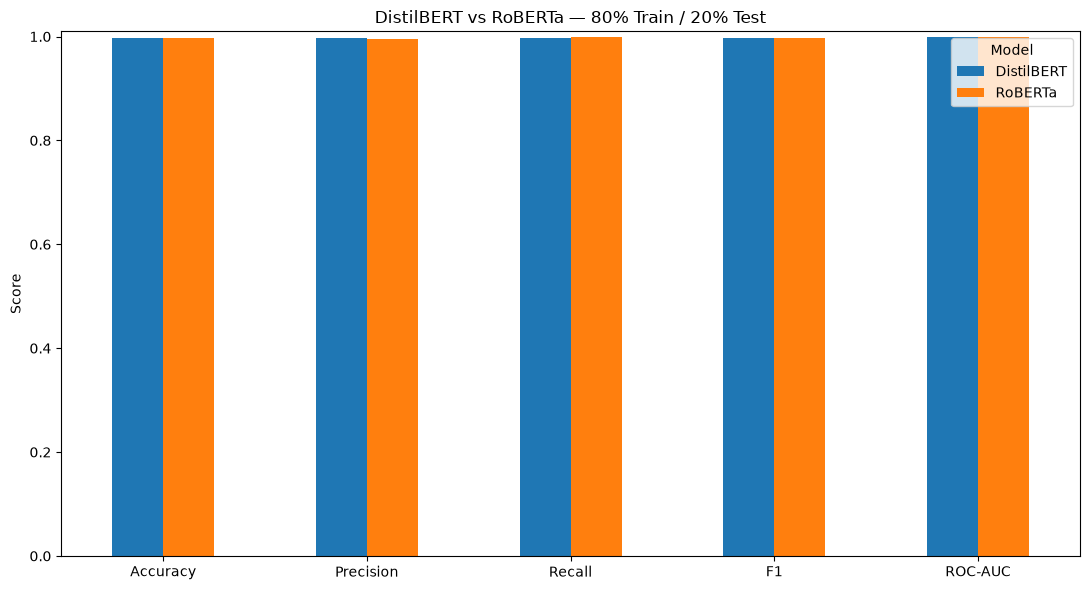

Saved: c:\Users\HOME\OneDrive\Máy tính\AI-Generated-Text-Essay-Detection\results\distilbert_roberta_80_20_earlystop\distilbert_roberta_80_20_results.csv
Saved: c:\Users\HOME\OneDrive\Máy tính\AI-Generated-Text-Essay-Detection\results\distilbert_roberta_80_20_earlystop\distilbert_roberta_80_20_metrics.png


In [9]:
results_df = pd.DataFrame([distil_result, roberta_result])

display(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "Best_val_F1_stage_A",
            "Selected_epoch",
            "Stage_A_seconds",
            "Stage_B_seconds",
            "Total_AB_seconds",
        ]
    ].sort_values("F1", ascending=False)
)

summary_path = RESULT_DIR / "distilbert_roberta_80_20_results.csv"
results_df.to_csv(summary_path, index=False)

plot_df = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]
ax = plot_df.T.plot(kind="bar", figsize=(11, 6))
ax.set_ylim(0, 1.01)
ax.set_ylabel("Score")
ax.set_title("DistilBERT vs RoBERTa — 80% Train / 20% Test")
plt.xticks(rotation=0)
plt.tight_layout()

fig_path = RESULT_DIR / "distilbert_roberta_80_20_metrics.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", summary_path)
print("Saved:", fig_path)

## Protocol summary

Final reporting protocol:

```text
100% Dataset
│
├── 80% Train Pool
│     │
│     ├── Stage A:
│     │     90% inner-train
│     │     10% validation
│     │     → Early Stopping → chọn best epoch
│     │
│     └── Stage B:
│           Retrain từ đầu trên FULL 80%
│           với best epoch đã chọn
│
└── 20% Test
      → chỉ evaluate cuối cùng
```

Do đó final model được train trên đủ **80% dữ liệu** và Test vẫn độc lập.